[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-ORG/YOUR-REPO/blob/main/CMPUT328_Assignment2.ipynb)

> In Colab: **Runtime → Change runtime type → GPU**, then run the cells top to bottom.

# CMPUT 328 — Assignment 2, Part 1 (4%)
## CIFAR-10 Classification with a Convolutional Neural Network

**Name:** Laurie Gantuangco
**Student ID:** 1771419

**Deadline:** 8 October 2026, 11:59 PM (Mountain Time)

Submit this notebook with all code, outputs and plots visible, together with the 1–2 page PDF report. Put your name and student ID on both. If you use Gemini or another AI assistant, document how you used it in the report.

### Rubric (each criterion is all-or-nothing)

| # | Component | Weight | Criteria |
| :-- | :-- | :-- | :-- |
| 1 | CNN architecture | 0.5% | Uses conv, ReLU and pooling layers; input stays `N×3×32×32`; flattening only before the classifier |
| 2 | Data pipeline | 0.5% | Provided 45k / 5k / 10k split used unchanged; normalization applied; seeds set |
| 3 | Sanity check | 0.5% | Overfits one 128-image batch to ≥95% accuracy (or loss < 0.1) within 200 iterations; result reported |
| 4 | Tensor shapes | 0.5% | Shape printed after every layer; spatial changes explained using kernel size, stride and padding |
| 5 | Training and curves | 0.5% | 30 epochs with Adam or SGD; per-epoch train/val loss and accuracy plotted; behaviour discussed |
| 6 | Performance | 0.5% | ≥80% validation accuracy at the final epoch with `FAST_MODE = False`; test accuracy reported once |
| 7 | Example predictions | 0.5% | Grid shows true and predicted labels, with both correct and incorrect examples |
| 8 | Interpretation | 0.5% | Discusses error patterns and relates them to the curves and final accuracy |

**Part 1 total = 4%**

### Learning goals
By the end of Part 1 you should be able to:
- Explain why a CNN keeps the image in its spatial form instead of flattening it at the input, and how spatial dimensions change layer to layer.
- Implement a compact CNN (Conv → ReLU → Pool blocks) in PyTorch and train it on CIFAR-10.
- Verify a training pipeline with sanity checks, and read training curves to judge whether a model is learning, underfitting or overfitting.

## 0. Setup
Imports, random seeds and device. **Do not change the seed**: Part 2 relies on the same data split.

In [1]:
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 328

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


### Run settings
`FAST_MODE` trains on a random subset of the 45,000 training images so the notebook runs quickly while you develop and debug. The validation and test sets are never reduced.

- Use `FAST_MODE = True` for development only.
- **Your submitted results and report must come from a full run with `FAST_MODE = False`.** The performance target in the rubric applies to that run.
- State the setting you used in your report.

In [13]:
FAST_MODE = False             # set to True for quick development; False for final results
FAST_MODE_TRAIN_SIZE = 10_000 # training images used only when FAST_MODE is True
BATCH_SIZE = 128
NUM_WORKERS = 2

Helpers

In [5]:
import os
# Commented out because I did this notebook locally.
# import shutil
# from google.colab import drive

# drive.mount('/content/drive')
# DRIVE_COPY = '/content/drive/MyDrive/cmput328/cifar-10-python.tar.gz'
# LOCAL_COPY = './data/cifar-10-python.tar.gz'
os.makedirs('./data', exist_ok=True)

# if os.path.exists(DRIVE_COPY):
#     shutil.copy(DRIVE_COPY, LOCAL_COPY)   # takes seconds
#     print('Copied CIFAR-10 archive from Drive')

def denormalize(img):
    '''Convert a normalized (3, H, W) tensor to an (H, W, 3) array in [0, 1] for plt.imshow.'''
    mean = torch.tensor(cifar_mean).view(3, 1, 1)
    std = torch.tensor(cifar_std).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

## 1. Data loading and normalization (Rubric 2)
The official 50,000 CIFAR-10 training images are split into **45,000 training** and **5,000 validation** images using a fixed seed. The official **10,000-image test set** is kept for final evaluation only.

The training and validation sets are built from two separate dataset objects so that the training-only augmentation (random crop with 4-pixel padding + horizontal flip) never leaks into validation or test. **Save the split indices** to `cifar10_split_seed328.npz` (keys `train_idx` with 45,000 indices and `val_idx` with 5,000 indices, both into the official training set). Part 2 loads this file, so both parts use the identical split. Save the full 45,000 training indices even when `FAST_MODE = True`.

In [16]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

# Training-only augmentation (same as Part 2): random crop with 4-pixel padding + horizontal flip
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

root = './data'
train_source = datasets.CIFAR10(root, train=True,  download=True, transform=train_tf)
val_source   = datasets.CIFAR10(root, train=True,  download=True, transform=eval_tf)
test_ds      = datasets.CIFAR10(root, train=False, download=True, transform=eval_tf)

# Fixed 45k / 5k split of the official training set
SPLIT_FILE = 'cifar10_split_seed328.npz'   # reused by Part 2 -- do not rename
split_indices = np.random.default_rng(SEED).permutation(len(train_source))
train_idx = split_indices[:45_000]
val_idx = split_indices[45_000:]
assert len(train_idx) == 45_000 and len(val_idx) == 5_000
np.savez(SPLIT_FILE, train_idx=train_idx, val_idx=val_idx)

selected_train_idx = train_idx[:FAST_MODE_TRAIN_SIZE] if FAST_MODE else train_idx
train_ds = Subset(train_source, selected_train_idx.tolist())
val_ds = Subset(val_source, val_idx.tolist())

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          worker_init_fn=seed_worker,
                          generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

print(f'FAST_MODE={FAST_MODE} | train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

FAST_MODE=False | train=45000  val=5000  test=10000


## 2. CNN architecture  *(Rubric 1)*
Implement a small CNN using convolutional layers, ReLU activations and pooling layers.

- The input must stay in its spatial form (`N × 3 × 32 × 32`) and pass through the convolutional layers first.
- Flattening is allowed **only** after the final convolution/pooling block, immediately before the fully connected classification layer(s).
- Suggested structure: `self.features` (conv/ReLU/pool blocks) followed by `self.classifier` (flatten + linear layers). Keep the model small.
- *Hint for reaching the 80% target:* you may add **BatchNorm** after each convolution and **dropout** in the classifier, and using **two conv layers per block** before each pooling layer (e.g. 3 blocks: 32→16→8→4) helps considerably. A plain 2–3 layer CNN without these usually plateaus in the low-to-mid 70s.

In [8]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x has shape (N, 3, 32, 32). Do NOT flatten before the convolutional blocks.
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

## 3. Training and evaluation functions (Rubric 3)
Implement one epoch of training and an evaluation function. Both should return the **average loss** and **accuracy** over the loader.

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    '''Train for one epoch. Returns (avg_loss, accuracy).'''
    model.train()
    model_device = next(model.parameters()).device
    loss_sum = 0.0
    correct = 0
    num_examples = 0

    for images, labels in loader:
        images = images.to(model_device, non_blocking=True)
        labels = labels.to(model_device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        num_examples += batch_size

    return loss_sum / num_examples, correct / num_examples


@torch.no_grad()
def evaluate(model, loader, criterion):
    '''Evaluate without updating weights. Returns (avg_loss, accuracy).'''
    model.eval()
    model_device = next(model.parameters()).device
    loss_sum = 0.0
    correct = 0
    num_examples = 0

    for images, labels in loader:
        images = images.to(model_device, non_blocking=True)
        labels = labels.to(model_device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        num_examples += batch_size

    return loss_sum / num_examples, correct / num_examples

## 4. Tensor shape check  *(Rubric 4)*
Pass a sample batch through the network and print the tensor shape after **every** layer (convolution, activation, pooling, flatten and linear).

*Hint:* iterate over the layers in `self.features` and `self.classifier`, or register forward hooks.

In [10]:
set_seed()
model = CIFAR10_CNN().to(device)
x = torch.randn(4, 3, 32, 32, device=device)

print(f'{"Input":30s} {tuple(x.shape)}')

with torch.no_grad():
    for layer_index, layer in enumerate(model.features, start=1):
        x = layer(x)
        print(f'{layer_index:02d} {layer.__class__.__name__:24s} {tuple(x.shape)}')

    x = torch.flatten(x, start_dim=1)
    print(f'{"Flatten":30s} {tuple(x.shape)}')

    for layer_index, layer in enumerate(model.classifier, start=1):
        x = layer(x)
        print(f'{"Classifier " + str(layer_index):30s} {layer.__class__.__name__:24s} {tuple(x.shape)}')

Input                          (4, 3, 32, 32)
01 Conv2d                   (4, 32, 32, 32)
02 BatchNorm2d              (4, 32, 32, 32)
03 ReLU                     (4, 32, 32, 32)
04 Conv2d                   (4, 32, 32, 32)
05 BatchNorm2d              (4, 32, 32, 32)
06 ReLU                     (4, 32, 32, 32)
07 MaxPool2d                (4, 32, 16, 16)
08 Conv2d                   (4, 64, 16, 16)
09 BatchNorm2d              (4, 64, 16, 16)
10 ReLU                     (4, 64, 16, 16)
11 Conv2d                   (4, 64, 16, 16)
12 BatchNorm2d              (4, 64, 16, 16)
13 ReLU                     (4, 64, 16, 16)
14 MaxPool2d                (4, 64, 8, 8)
15 Conv2d                   (4, 128, 8, 8)
16 BatchNorm2d              (4, 128, 8, 8)
17 ReLU                     (4, 128, 8, 8)
18 Conv2d                   (4, 128, 8, 8)
19 BatchNorm2d              (4, 128, 8, 8)
20 ReLU                     (4, 128, 8, 8)
21 MaxPool2d                (4, 128, 4, 4)
Flatten                        (4, 2048

The six convolutions all use a 3×3 kernel, stride 1 and padding 1, so each preserves height and width while changing the channel count: 3→32→32, 32→64→64, then 64→128→128. Each 2×2 max-pool uses stride 2 and no padding, halving the spatial dimensions: 32×32→16×16→8×8→4×4. Thus the final feature tensor is `N×128×4×4`. It is flattened only before the classifier, giving 2,048 features per image, then the linear layers map 2,048→256→10 classes.

## 5. Sanity check: overfit one batch  *(Rubric 3)*
Train a **fresh** model on a single fixed batch of 128 training images for up to 200 iterations.

The check passes if training accuracy on the batch reaches **at least 95%** or the loss falls **below 0.1**. Report the final loss and accuracy. If it fails, fix your model or training loop before continuing.

In [12]:
set_seed()
sanity_images, sanity_labels = next(iter(DataLoader(train_ds, batch_size=128, shuffle=False)))
sanity_images, sanity_labels = sanity_images.to(device), sanity_labels.to(device)

# Fresh, untrained model just for this check
sanity_model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(sanity_model.parameters(), lr=1e-3)

for iteration in range(1, 201):
    sanity_model.train()
    optimizer.zero_grad(set_to_none=True)
    logits = sanity_model(sanity_images)
    loss = criterion(logits, sanity_labels)
    loss.backward()
    optimizer.step()

    if iteration % 10 == 0 or iteration == 200:
        sanity_model.eval()
        with torch.no_grad():
            check_logits = sanity_model(sanity_images)
            check_loss = criterion(check_logits, sanity_labels).item()
            check_accuracy = (check_logits.argmax(dim=1) == sanity_labels).float().mean().item()

        if iteration == 10 or iteration % 25 == 0 or check_accuracy >= 0.95 or check_loss < 0.1:
            print(f'Iteration {iteration:3d}: eval loss={check_loss:.4f}, eval accuracy={check_accuracy:.2%}')
        if check_accuracy >= 0.95 or check_loss < 0.1:
            break

sanity_model.eval()
with torch.no_grad():
    final_logits = sanity_model(sanity_images)
    final_loss = criterion(final_logits, sanity_labels).item()
    final_accuracy = (final_logits.argmax(dim=1) == sanity_labels).float().mean().item()

print(f'Final sanity result: loss={final_loss:.4f}, accuracy={final_accuracy:.2%}, iterations={iteration}')
print('Sanity check passed' if final_accuracy >= 0.95 or final_loss < 0.1 else 'Sanity check not yet passed')

Iteration  10: eval loss=2.3151, eval accuracy=10.94%
Iteration  40: eval loss=0.0070, eval accuracy=100.00%
Final sanity result: loss=0.0070, accuracy=100.00%, iterations=40
Sanity check passed


## 6. Full training  *(Rubric 5)*
Train a fresh model for **30 epochs** with Adam or SGD. After each epoch, record training and validation loss and accuracy in `history`.

**Do not evaluate on the test set during training.** Record the time per epoch as well.

In [17]:
set_seed()
model = CIFAR10_CNN().to(device)
EPOCHS = 30

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    epoch_start = time.perf_counter()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    epoch_time = time.perf_counter() - epoch_start

    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)

    print(
        f'Epoch {epoch + 1:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc:.2%} | '
        f'val loss {val_loss:.4f}, acc {val_acc:.2%} | '
        f'train time {epoch_time:.1f}s'
    )

Epoch 01/30 | train loss 1.5396, acc 42.96% | val loss 1.1959, acc 56.82% | train time 5.5s
Epoch 02/30 | train loss 1.0918, acc 61.00% | val loss 0.8694, acc 68.14% | train time 5.5s
Epoch 03/30 | train loss 0.9098, acc 67.99% | val loss 0.9134, acc 69.16% | train time 5.5s
Epoch 04/30 | train loss 0.8062, acc 71.63% | val loss 0.7353, acc 74.50% | train time 5.4s
Epoch 05/30 | train loss 0.7449, acc 74.12% | val loss 0.8220, acc 71.00% | train time 5.3s
Epoch 06/30 | train loss 0.6848, acc 76.34% | val loss 0.6492, acc 77.60% | train time 5.4s
Epoch 07/30 | train loss 0.6427, acc 78.03% | val loss 0.5709, acc 79.50% | train time 5.3s
Epoch 08/30 | train loss 0.6090, acc 79.08% | val loss 0.6520, acc 77.98% | train time 5.4s
Epoch 09/30 | train loss 0.5714, acc 80.68% | val loss 0.6405, acc 77.34% | train time 5.3s
Epoch 10/30 | train loss 0.5436, acc 81.38% | val loss 0.5430, acc 81.56% | train time 5.5s
Epoch 11/30 | train loss 0.5126, acc 82.70% | val loss 0.5557, acc 81.02% | trai

### Save the trained model (recommended, not graded)
Saving the weights lets you reuse this CNN in Part 2 without retraining.

In [18]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': EPOCHS,
    'history': history,
    'fast_mode': FAST_MODE,
}
torch.save(checkpoint, 'cifar10_cnn_checkpoint.pt')
print(f'Saved checkpoint after {EPOCHS} epochs to cifar10_cnn_checkpoint.pt')

Saved checkpoint after 30 epochs to cifar10_cnn_checkpoint.pt


## 7. Training curves
Plot training and validation loss on one graph, and training and validation accuracy on another, both against epochs.

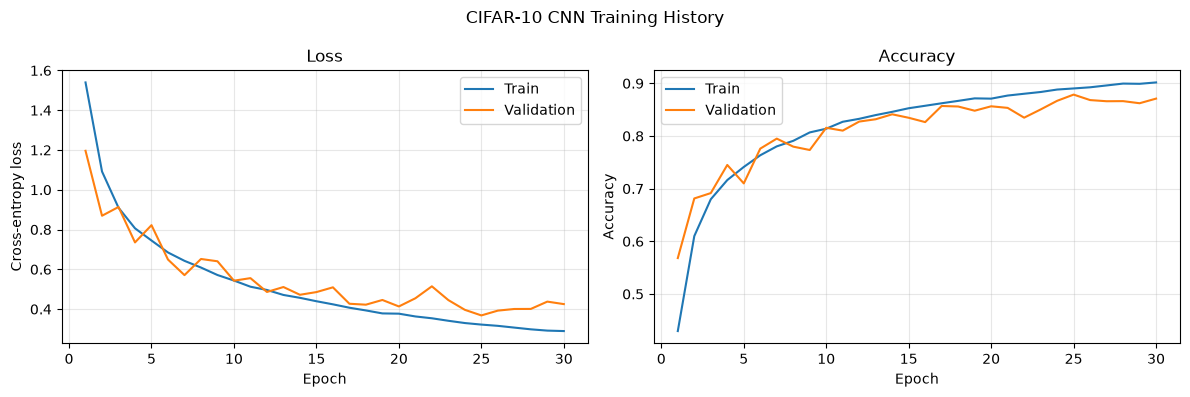

In [19]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Validation')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Validation')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('CIFAR-10 CNN Training History')
fig.tight_layout()
plt.show()

The model is learning: training loss fell from 1.5396 to 0.2897 and validation loss from 1.1959 to 0.4252. Training accuracy reached 90.17%, while final validation accuracy was 87.10%, a 3.07 percentage-point gap. Validation loss was lowest at epoch 25 (0.3683) and rose slightly afterward; validation accuracy also peaked at epoch 25 (87.86%) before ending at 87.10%. This suggests mild late overfitting, but not severe: validation accuracy remains above the 80% target and close to training accuracy.

## 8. Final evaluation  *(Rubric 6)*
Report the final validation accuracy, then evaluate **once** on the 10,000-image test set and report the test accuracy.

Target: at least **80% validation accuracy** at the final epoch with `FAST_MODE = False`.

In [20]:
final_val_loss, final_val_acc = evaluate(model, val_loader, criterion)
print(f'Final validation loss: {final_val_loss:.4f}')
print(f'Final validation accuracy: {final_val_acc:.2%}')

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.2%}')

Final validation loss: 0.4252
Final validation accuracy: 87.10%
Test loss: 0.4557
Test accuracy: 86.07%


## 9. Example predictions  *(Rubric 7)*
Show a grid of validation images with their true and predicted classes. Include **at least 8 correct and 8 incorrect** predictions.

Use `denormalize` to convert images back to a displayable range.

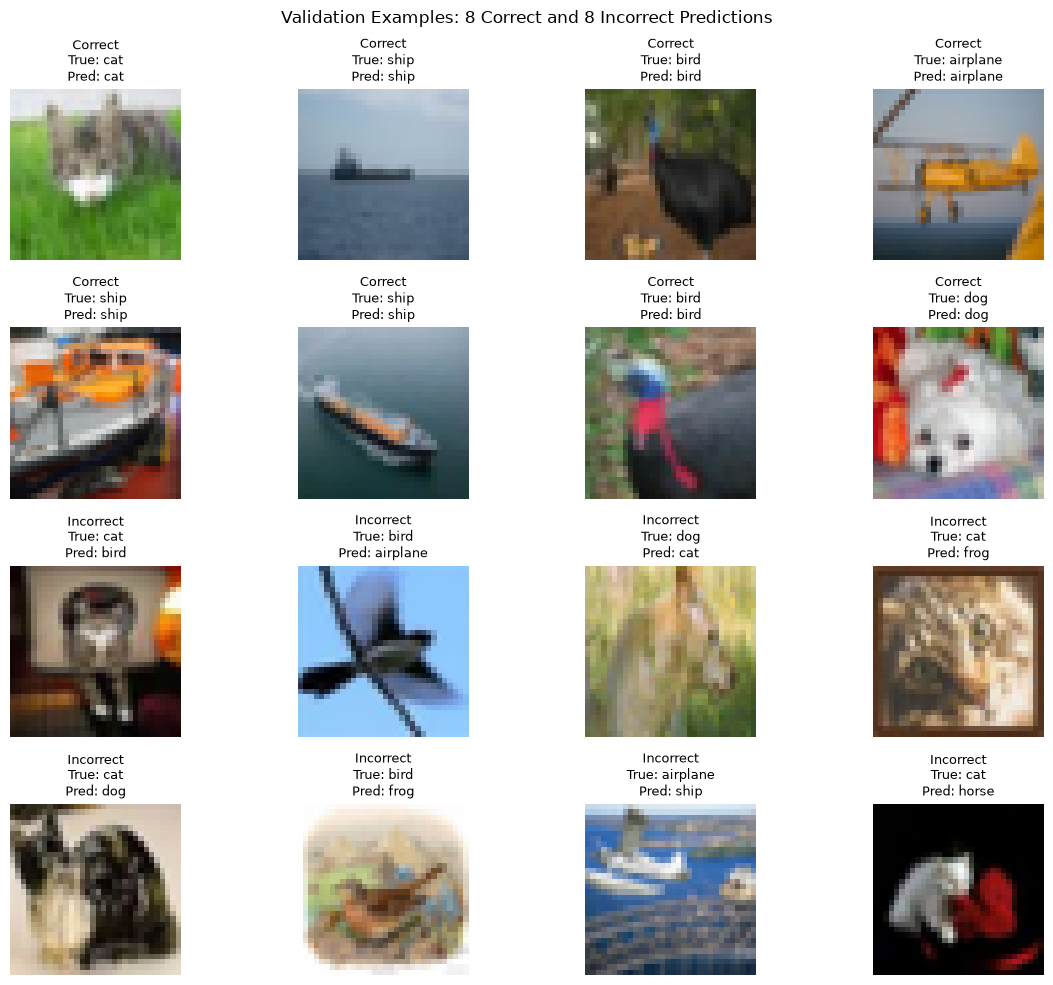

In [21]:
model.eval()
part1_val_image_batches = []
part1_val_label_batches = []
part1_val_prediction_batches = []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(device, non_blocking=True))
        part1_val_image_batches.append(images.cpu())
        part1_val_label_batches.append(labels.cpu())
        part1_val_prediction_batches.append(logits.argmax(dim=1).cpu())

part1_val_images = torch.cat(part1_val_image_batches)
part1_val_labels = torch.cat(part1_val_label_batches)
part1_val_predictions = torch.cat(part1_val_prediction_batches)
correct_indices = torch.where(part1_val_predictions == part1_val_labels)[0]
incorrect_indices = torch.where(part1_val_predictions != part1_val_labels)[0]
assert correct_indices.numel() >= 8 and incorrect_indices.numel() >= 8

selected_indices = torch.cat((correct_indices[:8], incorrect_indices[:8]))
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
for plot_index, (axis, image_index) in enumerate(zip(axes.flat, selected_indices.tolist())):
    axis.imshow(denormalize(part1_val_images[image_index]))
    true_label = CLASSES[part1_val_labels[image_index].item()]
    predicted_label = CLASSES[part1_val_predictions[image_index].item()]
    result = 'Correct' if plot_index < 8 else 'Incorrect'
    axis.set_title(f'{result}\nTrue: {true_label}\nPred: {predicted_label}', fontsize=9)
    axis.axis('off')

fig.suptitle('Validation Examples: 8 Correct and 8 Incorrect Predictions')
fig.tight_layout()
plt.show()

In the example grid, the model confuses visually similar low-resolution classes: cat images are predicted as bird, dog, frog, or horse; a bird is predicted as airplane or frog; a dog is predicted as cat; and an airplane is predicted as ship. At 32×32 resolution, shape and background cues can be ambiguous. The curves show strong learning with a small train/validation gap and a slight validation-loss rise after epoch 25. Final test accuracy (86.07%) is close to validation accuracy (87.10%), suggesting the sample confusions are consistent with residual class ambiguity rather than a large train/test generalization gap.

### Notes on Part 1 - Check that:
- [ ] Final run uses `FAST_MODE = False`, and the setting is stated in the report
- [ ] All cells run top to bottom without errors, with outputs and plots visible
- [ ] AI assistance (if any) is documented in the report


# CMPUT 328 — Assignment 2, Part 2 (5%)
## CIFAR-10 Classification with a ViT and LoRA Fine-Tuning

**Goal.** Train a compact Vision Transformer (ViT) from scratch on CIFAR-10, fine-tune an ImageNet-pretrained ViT with LoRA, and compare both against your Part 1 CNN, a linear probe and full fine-tuning in terms of accuracy and training cost.

| Section | Content |
|---|---|
| 1 | Data pipeline (45k / 5k / 10k split, seeds) |
| 2 | ViT from scratch, sanity checks, training |
| 3 | Training curves, CNN comparison |
| 4 | Pretrained ViT + linear probe |
| 5 | LoRA vs. full fine-tuning |
| 6 | Results table, confusion matrices, misclassified images |
| 7 | Controlled experiment |

### Rubric (each criterion is all-or-nothing)

| # | Component | Weight | Criteria |
| :-- | :-- | :-- | :-- |
| 1 | Data pipeline | 0.4% | 45,000 / 5,000 / 10,000 split correctly drawn from the official CIFAR-10 train/test sets and documented; all random seeds set (`torch.manual_seed`, `random.seed`, `np.random.seed`, e.g. 328) |
| 2 | Vision Transformer from scratch | 0.8% | Image is split into patches and tokenized (not flattened whole); includes patch embedding, learnable [CLS] token, positional embeddings, a stack of Transformer encoder blocks and a classification head. Both sanity checks present: tiny-batch overfit to near-100% accuracy, and tensor shapes printed after each stage. Trained 20–30 epochs with Adam/AdamW at a reasonable LR |
| 3 | Training dynamics and CNN comparison | 0.6% | Loss/accuracy plots included. CNN re-run on the identical split and a comparable epoch budget; test accuracy reported |
| 4 | Loading an ImageNet-pretrained ViT | 0.4% | Pretrained ViT loaded correctly with a new 10-class head; images resized to 224×224 and normalized with the pretrained model's stats. Backbone fully frozen for the linear probe (1–2 epochs); test accuracy reported |
| 5 | LoRA fine-tuning | 0.8% | LoRA adapters injected into attention projections via `peft`, with a stated rank; classification head kept trainable. Full fine-tuning run with the same epoch budget. All four quantities reported for both: trainable params (and %), time/epoch, peak GPU memory, test accuracy |
| 6 | Results comparison | 0.6% | Summary table across all models. Confusion matrices for both scratch ViT and LoRA. Grid of ≥16 misclassified LoRA images with predicted/true labels |
| 7 | Controlled experiment | 0.4% | One deliberate, clearly stated change, run and reported |
| — | Report | 1.0% | See the assignment description |

**Part 2 total = 5%**

**How to run.** Use a GPU runtime (Colab T4 or better). The 224×224 ViT-Base runs (sections 4, 5, 7) dominate the runtime. If it is too slow, or full fine-tuning runs out of memory, lower `PT_N_TRAIN` / `PT_BATCH` in the config cell and state what you changed in your report.

Fill in every `## YOUR CODE GOES HERE` / `# TODO` block, run the notebook top to bottom, and answer the ✏️ discussion cells using your own numbers and plots.

In [ ]:
# Dependencies are installed in the project's local .venv from requirements.txt.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import copy, gc, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from sklearn.metrics import confusion_matrix

try:
    from IPython.display import display
except ImportError:  # plain-python fallback
    display = print

# ------------------------------------------------------------------ config
SMOKE = False   # True = tiny subsets / 1 epoch, only to check that the code runs end-to-end
SEED = 328
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = "./data"                        # same folder as Part 1
NUM_WORKERS = 0                        # avoid notebook subprocess/pickling issues locally

# split sizes (train/val come from the 50k official training set; test = official 10k test set)
N_TRAIN, N_VAL, N_TEST = 45_000, 5_000, 10_000

# --- from-scratch ViT and CNN
EPOCHS_SCRATCH = 30                    # assignment: 20-30 epochs
BATCH_SCRATCH = 128
LR_VIT = 3e-4
EPOCHS_CNN = 30                        # comparable budget to the ViT
LR_CNN = 1e-3

# --- pretrained ViT-Base @ 224x224 (expensive: lower PT_N_TRAIN / PT_BATCH if needed)
PT_NAME = "google/vit-base-patch16-224-in21k"
PT_N_TRAIN, PT_N_VAL, PT_N_TEST = 45_000, 5_000, 10_000
PT_BATCH = 8                           # reduced from 64 for 16 GB GPU memory
EPOCHS_LP = 2                          # linear probe: 1-2 epochs
EPOCHS_FT = 3                          # LoRA and full FT share this budget (2-3 epochs)
LR_LP, LR_LORA, LR_FULL = 2e-3, 1e-3, 2e-5
LORA_R = 8

OVERFIT_STEPS = 300

if SMOKE:
    N_TRAIN, N_VAL, N_TEST = 512, 256, 256
    EPOCHS_SCRATCH = EPOCHS_CNN = EPOCHS_LP = EPOCHS_FT = 1
    PT_N_TRAIN, PT_N_VAL, PT_N_TEST, PT_BATCH = 32, 16, 16, 16
    OVERFIT_STEPS = 30

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
print(f"torch {torch.__version__} | device: {DEVICE} | seed: {SEED}")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch 2.14.1+cu130 | device: cuda | seed: 328
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


The 50,000 official CIFAR-10 training indices were permuted with `np.random.default_rng(328)`. The first 45,000 indices form the training set and the remaining 5,000 form validation; the official 10,000 test images remain separate. Both index arrays are saved in `cifar10_split_seed328.npz` and reused unchanged across all models. Training-only augmentation is applied to the training data; validation and test data use deterministic normalization.

In [33]:
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

raw_train = CIFAR10(ROOT, train=True, download=True)      # un-transformed, used to display images
CLASSES = raw_train.classes

SPLIT_FILE = "cifar10_split_seed328.npz"    # saved in Part 1, section 1
if not os.path.exists(SPLIT_FILE):
    raise FileNotFoundError(f"{SPLIT_FILE} not found - run Part 1, section 1 first.")

with np.load(SPLIT_FILE) as split:
    TRAIN_IDX = split["train_idx"].astype(np.int64).tolist()
    VAL_IDX = split["val_idx"].astype(np.int64).tolist()

assert len(TRAIN_IDX) == 45_000
assert len(VAL_IDX) == 5_000
assert not set(TRAIN_IDX).intersection(VAL_IDX)
assert sorted(TRAIN_IDX + VAL_IDX) == list(range(len(raw_train.targets)))

def make_loaders(mean, std, aug, batch_size, n_train, n_val, n_test):
    """Train (augmented, shuffled), val and test (deterministic) loaders for a given normalization."""
    norm = [T.ToTensor(), T.Normalize(mean, std)]
    train_tf, eval_tf = T.Compose(aug + norm), T.Compose(norm)
    ds_train = CIFAR10(ROOT, train=True, transform=train_tf)
    ds_eval = CIFAR10(ROOT, train=True, transform=eval_tf)
    ds_test = CIFAR10(ROOT, train=False, transform=eval_tf)
    g = torch.Generator().manual_seed(SEED)
    kw = dict(num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
    train_loader = DataLoader(Subset(ds_train, TRAIN_IDX[:n_train]), batch_size, shuffle=True, generator=g,
                              worker_init_fn=lambda w: np.random.seed(SEED + w), **kw)
    val_loader = DataLoader(Subset(ds_eval, VAL_IDX[:n_val]), batch_size * 2, shuffle=False, **kw)
    test_loader = DataLoader(Subset(ds_test, list(range(n_test))), batch_size * 2, shuffle=False, **kw)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    CIFAR_MEAN, CIFAR_STD, [T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()],
    BATCH_SCRATCH, N_TRAIN, N_VAL, N_TEST)

targets = np.array(raw_train.targets)
print(f"train: {len(train_loader.dataset)} | val: {len(val_loader.dataset)} | test: {len(test_loader.dataset)}")
print("train/val overlap:", len(set(TRAIN_IDX) & set(VAL_IDX)))
print("val class counts  :", np.bincount(targets[VAL_IDX[:N_VAL]], minlength=10))
print("train class counts:", np.bincount(targets[TRAIN_IDX[:N_TRAIN]], minlength=10))

train: 45000 | val: 5000 | test: 10000
train/val overlap: 0
val class counts  : [544 530 524 515 459 498 438 479 515 498]
train class counts: [4456 4470 4476 4485 4541 4502 4562 4521 4485 4502]


## 2. Vision Transformer from scratch  *(Rubric 2)*

Implement a compact ViT for 32×32 CIFAR-10 images. **Do not flatten the whole image at the input** — split it into patches and tokenize them. Your model must include:

1. **Patch embedding** — cut the image into non-overlapping patches (e.g. 4×4 → 8×8 = 64 patches) and project each patch to a `dim`-dimensional token. *Hint:* a `Conv2d` with `kernel_size = stride = patch` is equivalent to flattening each patch and applying a shared linear layer.
2. A learnable **[CLS]** token prepended to the patch tokens.
3. Learnable **positional embeddings** added to all tokens.
4. A stack of **Transformer encoder blocks** (e.g. pre-norm: `x = x + MHSA(LN(x))`, `x = x + MLP(LN(x))`).
5. A final LayerNorm, then a **linear classification head** on the [CLS] token (10 classes).

Suggested size (a few million parameters): `dim=256, depth=8, heads=8, mlp_ratio=2, drop=0.1`. Keep the constructor signature below; later cells call `ViT()` and `ViT(drop=0.0)`.

When `verbose=True`, `ViT.forward` should print the tensor shape after **each stage** (used for sanity check (b)).

In [34]:
class PatchEmbed(nn.Module):
    def __init__(self, patch=4, in_ch=3, dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)

    def forward(self, x):
        # x: (B, 3, 32, 32) -> (B, num_patches, dim)
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)


class Attention(nn.Module):
    '''Multi-head self-attention.'''
    def __init__(self, dim, heads, drop):
        super().__init__()
        if dim % heads != 0:
            raise ValueError('dim must be divisible by heads')
        self.heads = heads
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(drop)

    def forward(self, x):
        batch_size, token_count, dim = x.shape
        qkv = self.qkv(x).reshape(batch_size, token_count, 3, self.heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        query, key, value = qkv.unbind(0)

        attention = (query @ key.transpose(-2, -1)) * self.scale
        attention = self.attn_drop(attention.softmax(dim=-1))
        x = attention @ value
        x = x.transpose(1, 2).reshape(batch_size, token_count, dim)
        return self.proj_drop(self.proj(x))


class Block(nn.Module):
    '''One pre-norm Transformer encoder block with residual connections.'''
    def __init__(self, dim, heads, mlp_ratio, drop):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, heads, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, img=32, patch=4, dim=256, depth=8, heads=8, mlp_ratio=2, n_classes=10, drop=0.1):
        super().__init__()
        if img % patch != 0:
            raise ValueError('img size must be divisible by patch size')
        self.patch_embed = PatchEmbed(patch=patch, in_ch=3, dim=dim)
        num_patches = (img // patch) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, dim))
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([
            Block(dim, heads, mlp_ratio, drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)
        self.apply(self._init_weights)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x, verbose=False):
        log = (lambda name, tensor: print(f'{name:<34}{tuple(tensor.shape)}')) if verbose else (lambda *args: None)
        log('input image', x)
        x = self.patch_embed(x)
        log('patch tokens', x)
        cls_token = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        log('prepend CLS token', x)
        x = x + self.pos_embed
        log('add positional embeddings', x)
        x = self.pos_drop(x)
        log('position dropout', x)
        for block_index, block in enumerate(self.blocks, start=1):
            x = block(x)
            log(f'encoder block {block_index}', x)
        x = self.norm(x)
        log('final layer norm', x)
        x = x[:, 0]
        log('select CLS token', x)
        x = self.head(x)
        log('classification head', x)
        return x


def count_params(model):
    '''Returns (number of trainable parameters, total number of parameters).'''
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    total = sum(parameter.numel() for parameter in model.parameters())
    return trainable, total


vit = ViT().to(DEVICE)
print(f'ViT parameters: {count_params(vit)[1] / 1e6:.2f} M')

ViT parameters: 4.25 M


### Sanity check (b): tensor shapes after every stage

In [35]:
vit.eval()
with torch.no_grad():
    _ = vit(torch.randn(4, 3, 32, 32, device=DEVICE), verbose=True)

input image                       (4, 3, 32, 32)
patch tokens                      (4, 64, 256)
prepend CLS token                 (4, 65, 256)
add positional embeddings         (4, 65, 256)
position dropout                  (4, 65, 256)
encoder block 1                   (4, 65, 256)
encoder block 2                   (4, 65, 256)
encoder block 3                   (4, 65, 256)
encoder block 4                   (4, 65, 256)
encoder block 5                   (4, 65, 256)
encoder block 6                   (4, 65, 256)
encoder block 7                   (4, 65, 256)
encoder block 8                   (4, 65, 256)
final layer norm                  (4, 65, 256)
select CLS token                  (4, 256)
classification head               (4, 10)


### Training utilities (shared by every model in this notebook)

* `evaluate` (provided) — returns average loss, accuracy, predictions and labels over a loader.
* `fit` — **implement it.** Train with AdamW over the *trainable* parameters only, and record per epoch: training loss & accuracy, validation loss & accuracy, and the wall-clock time of the **training part** of the epoch. Optional but recommended: linear LR warm-up then cosine decay, gradient clipping, and mixed precision (`torch.autocast` + `GradScaler`) on GPU.
* `run_experiment` — trains a model, then measures test accuracy, trainable parameters, mean time per epoch and **peak GPU memory** (`torch.cuda.max_memory_allocated()`), and stores everything for the final table. **Complete the TODOs.**

In [26]:
def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

@torch.no_grad()
def evaluate(model, loader, amp=True):
    model.eval()
    model_device = next(model.parameters()).device
    crit = nn.CrossEntropyLoss(reduction="sum")
    loss_sum, preds, labels = 0.0, [], []
    for x, y in loader:
        x = x.to(model_device, non_blocking=True)
        y = y.to(model_device, non_blocking=True)
        with torch.autocast(
            device_type=model_device.type,
            dtype=torch.float16,
            enabled=amp and model_device.type == "cuda",
        ):
            logits = model(x)
        loss_sum += crit(logits.float(), y).item()
        preds.append(logits.argmax(1).cpu())
        labels.append(y.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return loss_sum / len(labels), float((preds == labels).mean()), preds, labels


def fit(model, train_loader, val_loader, epochs, lr, weight_decay=0.0, warmup_frac=0.05, clip=1.0, amp=True, name=""):
    '''Train `model` and return per-epoch losses, accuracies, and training time.'''
    params = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if not params:
        raise ValueError("model has no trainable parameters")
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    model_device = next(model.parameters()).device
    amp_enabled = amp and model_device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
    total_steps = max(epochs * len(train_loader), 1)
    warmup_steps = int(total_steps * warmup_frac)

    def lr_scale(step):
        if warmup_steps and step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_scale)
    hist = defaultdict(list)

    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        correct = 0
        num_examples = 0
        sync()
        start_time = time.perf_counter()

        for x, y in train_loader:
            x = x.to(model_device, non_blocking=True)
            y = y.to(model_device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=model_device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                logits = model(x)
                loss = nn.CrossEntropyLoss()(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if clip is not None:
                torch.nn.utils.clip_grad_norm_(params, clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            batch_size = y.size(0)
            loss_sum += loss.item() * batch_size
            correct += (logits.detach().argmax(1) == y).sum().item()
            num_examples += batch_size

        sync()
        epoch_time = time.perf_counter() - start_time
        train_loss = loss_sum / num_examples
        train_acc = correct / num_examples
        val_loss, val_acc, _, _ = evaluate(model, val_loader, amp=amp)
        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        hist["epoch_time"].append(epoch_time)
        print(
            f"{name} | epoch {epoch + 1:02d}/{epochs} | "
            f"train loss {train_loss:.4f}, acc {train_acc:.2%} | "
            f"val loss {val_loss:.4f}, acc {val_acc:.2%} | "
            f"train time {epoch_time:.1f}s"
        )

    return dict(hist)


RESULTS, HISTORY, VAL_PREDS = {}, {}, {}      # filled by run_experiment; used in sections 3, 6, 7

def cleanup():
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

def run_experiment(name, model, loaders, epochs, lr, weight_decay=0.0):
    tr, va, te = loaders
    model.to(DEVICE)
    trainable, total = count_params(model)
    print(f"\n=== {name} | trainable {trainable:,} / {total:,} ({100 * trainable / total:.2f}%) ===")
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    hist = fit(model, tr, va, epochs, lr, weight_decay, name=name)

    peak = (torch.cuda.max_memory_allocated() / (1024 ** 2) if DEVICE.type == "cuda" else float("nan"))
    _, val_acc, val_pred, val_lab = evaluate(model, va)
    _, test_acc, _, _ = evaluate(model, te)
    RESULTS[name] = dict(
        test_acc=100 * test_acc,
        val_acc=100 * val_acc,
        trainable=trainable,
        total=total,
        pct_trainable=100 * trainable / total,
        sec_per_epoch=float(np.mean(hist["epoch_time"])),
        peak_mem_mb=peak,
        epochs=epochs,
    )
    HISTORY[name], VAL_PREDS[name] = hist, (val_pred, val_lab)
    print(
        f"--> {name}: val acc {100 * val_acc:.2f}% | test acc {100 * test_acc:.2f}% | "
        f"{RESULTS[name]['sec_per_epoch']:.1f} s/epoch | peak mem {peak:.0f} MB"
    )
    return hist

### Sanity check (a): overfit a tiny batch

Train a **fresh** ViT (no dropout) on a single fixed batch of 128 training images (no augmentation) for `OVERFIT_STEPS` iterations. If the model, loss, optimizer and data plumbing are correct, the loss should go to ~0 and the accuracy to ~100%. Print the loss and accuracy periodically and report the final accuracy.

In [36]:
set_seed()
tiny_ds = Subset(CIFAR10(ROOT, train=True, transform=T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])), TRAIN_IDX[:128])
xb, yb = next(iter(DataLoader(tiny_ds, batch_size=128, num_workers=0)))
xb, yb = xb.to(DEVICE), yb.to(DEVICE)

tiny_model = ViT(drop=0.0).to(DEVICE)
opt = torch.optim.Adam(tiny_model.parameters(), lr=1e-3)
tiny_criterion = nn.CrossEntropyLoss()

for step in range(1, OVERFIT_STEPS + 1):
    tiny_model.train()
    opt.zero_grad(set_to_none=True)
    logits = tiny_model(xb)
    loss = tiny_criterion(logits, yb)
    loss.backward()
    opt.step()

    if step == 1 or step % 25 == 0 or step == OVERFIT_STEPS:
        tiny_model.eval()
        with torch.no_grad():
            eval_logits = tiny_model(xb)
            eval_loss = tiny_criterion(eval_logits, yb).item()
            eval_acc = (eval_logits.argmax(1) == yb).float().mean().item()
        print(f'Step {step:3d}/{OVERFIT_STEPS}: loss={eval_loss:.4f}, accuracy={eval_acc:.2%}')
        if eval_acc >= 0.99 or eval_loss < 0.01:
            break

tiny_model.eval()
with torch.no_grad():
    final_logits = tiny_model(xb)
    final_loss = tiny_criterion(final_logits, yb).item()
    final_acc = (final_logits.argmax(1) == yb).float().mean().item()
print(f'ViT overfit sanity result: loss={final_loss:.4f}, accuracy={final_acc:.2%}, steps={step}')

del tiny_model, opt
cleanup()

Step   1/300: loss=2.1459, accuracy=27.34%
Step  25/300: loss=1.3078, accuracy=55.47%
Step  50/300: loss=0.1458, accuracy=98.44%
Step  75/300: loss=0.0063, accuracy=100.00%
ViT overfit sanity result: loss=0.0063, accuracy=100.00%, steps=75


The scratch ViT was trained for **30 epochs** on all 45,000 training images with AdamW, learning rate `3e-4`, weight decay `0.05`, and batch size `128`. It finished with 82.21% training accuracy and 78.24% validation accuracy; the lowest validation loss was 0.6206 at epoch 25. Held-out test accuracy was 78.43%.

In [37]:
set_seed()
vit = ViT()
hist_vit = run_experiment("ViT (scratch)", vit, (train_loader, val_loader, test_loader),
                          EPOCHS_SCRATCH, LR_VIT, weight_decay=0.05)
del vit; cleanup()


=== ViT (scratch) | trainable 4,249,354 / 4,249,354 (100.00%) ===
ViT (scratch) | epoch 01/30 | train loss 1.9322, acc 27.23% | val loss 1.8522, acc 32.04% | train time 9.5s
ViT (scratch) | epoch 02/30 | train loss 1.5958, acc 41.36% | val loss 1.5239, acc 44.70% | train time 9.6s
ViT (scratch) | epoch 03/30 | train loss 1.3627, acc 50.37% | val loss 1.2496, acc 54.80% | train time 9.4s
ViT (scratch) | epoch 04/30 | train loss 1.2390, acc 55.16% | val loss 1.1447, acc 58.56% | train time 9.5s
ViT (scratch) | epoch 05/30 | train loss 1.1663, acc 57.85% | val loss 1.0814, acc 60.28% | train time 9.5s
ViT (scratch) | epoch 06/30 | train loss 1.1069, acc 60.12% | val loss 1.0492, acc 62.74% | train time 9.4s
ViT (scratch) | epoch 07/30 | train loss 1.0594, acc 62.01% | val loss 1.0128, acc 63.60% | train time 9.6s
ViT (scratch) | epoch 08/30 | train loss 1.0145, acc 63.57% | val loss 1.0004, acc 64.22% | train time 9.7s
ViT (scratch) | epoch 09/30 | train loss 0.9771, acc 65.10% | val los

## 3. Training dynamics and comparison with the CNN  *(Rubric 3)*
Implement `plot_history` to plot **training vs. validation loss** and **training vs. validation accuracy** against epochs (two subplots). `curve_summary` (provided) prints the final gap and where the validation loss is lowest.

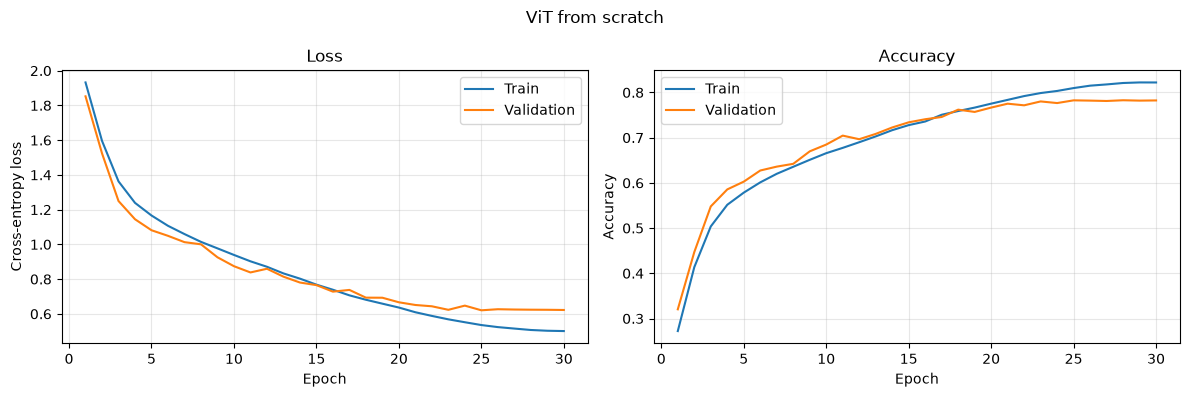

ViT (scratch): final train acc 0.822 | final val acc 0.782 | gap +0.040 | min val loss 0.621 at epoch 25 | final val loss 0.622


In [38]:
def plot_history(hist, title):
    '''Two side-by-side plots: train/val loss and train/val accuracy vs. epoch.'''
    epochs = range(1, len(hist['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist['train_loss'], label='Train')
    axes[0].plot(epochs, hist['val_loss'], label='Validation')
    axes[0].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist['train_acc'], label='Train')
    axes[1].plot(epochs, hist['val_acc'], label='Validation')
    axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def curve_summary(name):
    h = HISTORY[name]
    print(f"{name}: final train acc {h['train_acc'][-1]:.3f} | final val acc {h['val_acc'][-1]:.3f} | "
          f"gap {h['train_acc'][-1] - h['val_acc'][-1]:+.3f} | min val loss {min(h['val_loss']):.3f} at epoch "
          f"{int(np.argmin(h['val_loss'])) + 1} | final val loss {h['val_loss'][-1]:.3f}")

plot_history(HISTORY['ViT (scratch)'], 'ViT from scratch')
curve_summary('ViT (scratch)')

The training and validation curves improve throughout most of the 30 epochs. The final training accuracy is 82.21% and validation accuracy is 78.24%, a 3.97 percentage-point gap. Validation loss reaches its minimum of 0.6206 at epoch 25, then plateaus near 0.62 through epoch 30 while training loss continues to fall. This suggests mild late overfitting, but the gap remains modest. The scratch ViT is still learning at the final epoch, though its validation accuracy is below the CNN baseline.


=== CNN (Part 1) | trainable 815,018 / 815,018 (100.00%) ===
CNN (Part 1) | epoch 01/30 | train loss 1.6313, acc 39.60% | val loss 1.5418, acc 44.88% | train time 5.5s
CNN (Part 1) | epoch 02/30 | train loss 1.1222, acc 59.60% | val loss 0.9258, acc 66.76% | train time 5.5s
CNN (Part 1) | epoch 03/30 | train loss 0.9045, acc 67.87% | val loss 0.9393, acc 67.92% | train time 5.6s
CNN (Part 1) | epoch 04/30 | train loss 0.7844, acc 72.54% | val loss 0.8073, acc 72.32% | train time 5.6s
CNN (Part 1) | epoch 05/30 | train loss 0.6958, acc 75.85% | val loss 0.6906, acc 76.42% | train time 5.5s
CNN (Part 1) | epoch 06/30 | train loss 0.6381, acc 77.98% | val loss 0.6656, acc 78.02% | train time 5.4s
CNN (Part 1) | epoch 07/30 | train loss 0.5907, acc 79.64% | val loss 0.5716, acc 81.02% | train time 5.3s
CNN (Part 1) | epoch 08/30 | train loss 0.5501, acc 81.11% | val loss 0.6165, acc 78.94% | train time 5.3s
CNN (Part 1) | epoch 09/30 | train loss 0.5081, acc 82.78% | val loss 0.5436, acc 

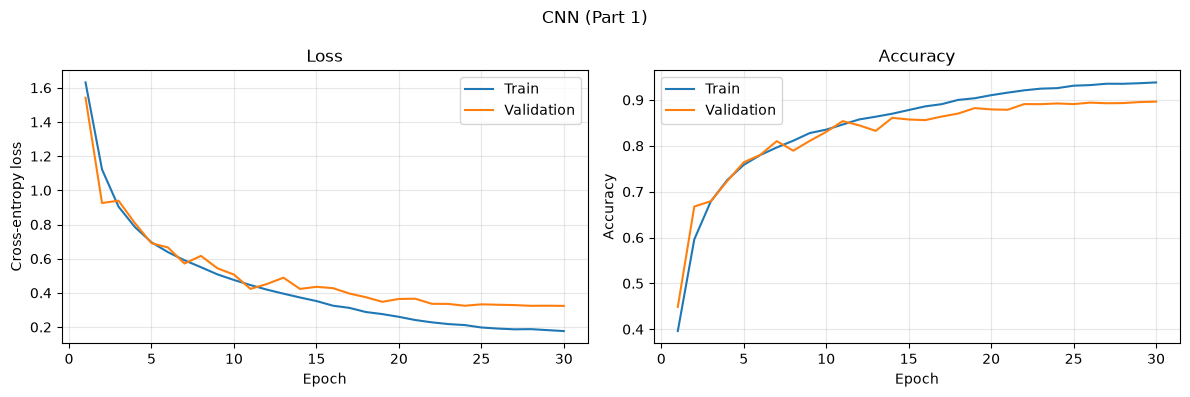

CNN (Part 1): final train acc 0.938 | final val acc 0.896 | gap +0.042 | min val loss 0.324 at epoch 30 | final val loss 0.324

Test accuracy — ViT (scratch): 78.43% | CNN (Part 1): 89.00%


In [39]:
CNN_NAME = "CNN (Part 1)"

set_seed()
cnn_baseline = CIFAR10_CNN().to(DEVICE)
run_experiment(CNN_NAME, cnn_baseline, (train_loader, val_loader, test_loader),
               EPOCHS_CNN, LR_CNN)

plot_history(HISTORY[CNN_NAME], CNN_NAME)
curve_summary(CNN_NAME)
print(f"\nTest accuracy — ViT (scratch): {RESULTS['ViT (scratch)']['test_acc']:.2f}% | "
      f"{CNN_NAME}: {RESULTS[CNN_NAME]['test_acc']:.2f}%")

On the identical split and 30-epoch budget, the Part 1 CNN reached 89.00% test accuracy, compared with 78.43% for the scratch ViT. The CNN's convolution and pooling layers encode locality and translation-related image structure, which is a useful inductive bias for small 32×32 images. The ViT must learn those relationships from data; patch tokens and the same dataset/training budget may be less effective without pretraining. The curves show both models learning, but the CNN reaches higher validation accuracy (89.64% versus 78.24%).

## 4. ImageNet-pretrained ViT and linear-probe baseline  *(Rubric 4)*

Load `google/vit-base-patch16-224-in21k` (ViT-Base, 16×16 patches, 224×224 input, pretrained on ImageNet-21k) with `ViTForImageClassification`, replacing its head with a **new 10-class head** (the Hugging Face warning about newly initialised `classifier` weights is expected).

- Normalize inputs with the checkpoint's **own** mean/std (from `ViTImageProcessor`).
- Resize CIFAR-10 images to **224×224**. *Tip:* keeping images at 32×32 in the DataLoader and resizing on the GPU inside the model wrapper (`F.interpolate`, bilinear) is much faster than resizing with PIL on the CPU.

**Linear probe:** freeze the **entire backbone** and train only the new head for 1–2 epochs, then report the test accuracy.

In [40]:
from transformers import ViTForImageClassification, ViTImageProcessor

proc = ViTImageProcessor.from_pretrained(PT_NAME)
PT_MEAN, PT_STD = tuple(proc.image_mean), tuple(proc.image_std)
print("pretrained normalisation:", PT_MEAN, PT_STD, "| expected input size:", proc.size)

pt_loaders = make_loaders(PT_MEAN, PT_STD, [T.RandomHorizontalFlip()], PT_BATCH, PT_N_TRAIN, PT_N_VAL, PT_N_TEST)
print(f"pretrained-model data: train {len(pt_loaders[0].dataset)} | val {len(pt_loaders[1].dataset)} | test {len(pt_loaders[2].dataset)} | batch {PT_BATCH}")


class HFViT(nn.Module):
    '''Resizes 32x32 -> 224x224, then runs a Hugging Face ViT and returns logits.'''
    def __init__(self, hf_model):
        super().__init__()
        self.m = hf_model

    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        return self.m(pixel_values=x).logits


def load_pretrained_vit():
    '''Returns a fresh pretrained ViTForImageClassification with a 10-class head.'''
    set_seed()
    return ViTForImageClassification.from_pretrained(
        PT_NAME,
        num_labels=10,
        ignore_mismatched_sizes=True,
    )

/home/laurie/CMPUT328/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pretrained normalisation: (0.5, 0.5, 0.5) (0.5, 0.5, 0.5) | expected input size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None)
pretrained-model data: train 45000 | val 5000 | test 10000 | batch 8


In [41]:
lp_hf = load_pretrained_vit()
for parameter in lp_hf.parameters():
    parameter.requires_grad = False
for parameter in lp_hf.classifier.parameters():
    parameter.requires_grad = True

print("trainable tensors:", [name for name, parameter in lp_hf.named_parameters() if parameter.requires_grad])
run_experiment("Linear probe", HFViT(lp_hf), pt_loaders, EPOCHS_LP, LR_LP)
del lp_hf
cleanup()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 22599.11it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable tensors: ['classifier.weight', 'classifier.bias']

=== Linear probe | trainable 7,690 / 85,806,346 (0.01%) ===
Linear probe | epoch 01/2 | train loss 0.1983, acc 95.31% | val loss 0.1107, acc 96.72% | train time 48.5s
Linear probe | epoch 02/2 | train loss 0.0835, acc 97.40% | val loss 0.1073, acc 96.74% | train time 48.9s
--> Linear probe: val acc 96.74% | test acc 96.46% | 48.7 s/epoch | peak mem 493 MB


LoRA configuration: rank `r=8`, alpha `16`, dropout `0.1`, attention query/value projections (`q_proj` and `v_proj`), trainable classifier head, learning rate `1e-3`, and 3 epochs. The full fine-tuning comparison uses the same data, batch size (`PT_BATCH=8`), and epoch budget, with learning rate `2e-5`.

In [ ]:
# Workaround for a torchao / peft incompatibility on some Colab images, not needed in local
#!pip uninstall -y -q torchao

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 14582.48it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA config: rank=8, alpha=16, dropout=0.1, targets=['q_proj', 'v_proj']
trainable params: 302,602 || all params: 86,108,948 || trainable%: 0.3514

=== LoRA (r=8) | trainable 302,602 / 86,108,948 (0.35%) ===
LoRA (r=8) | epoch 01/3 | train loss 0.1860, acc 95.60% | val loss 0.0768, acc 98.00% | train time 103.1s
LoRA (r=8) | epoch 02/3 | train loss 0.0513, acc 98.62% | val loss 0.0587, acc 98.52% | train time 103.1s
LoRA (r=8) | epoch 03/3 | train loss 0.0099, acc 99.74% | val loss 0.0546, acc 98.78% | train time 103.5s
--> LoRA (r=8): val acc 98.78% | test acc 98.41% | 103.2 s/epoch | peak mem 1036 MB


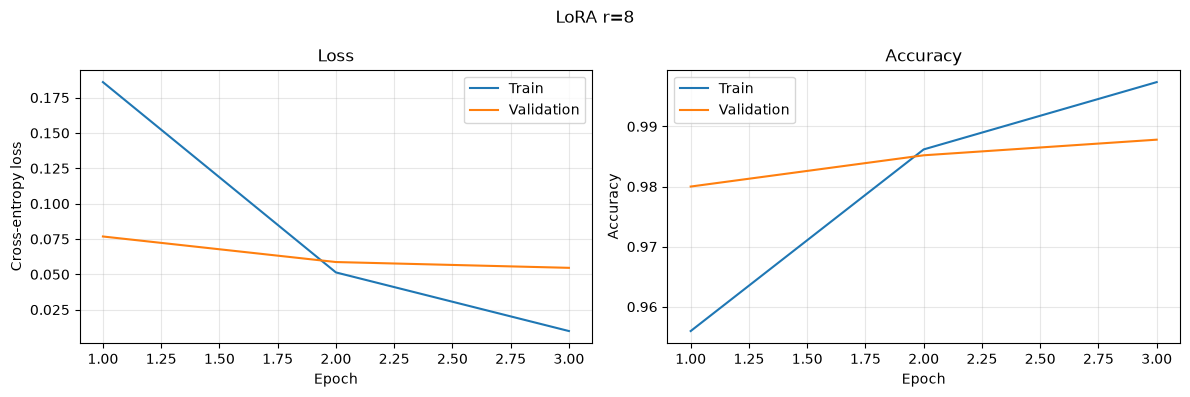

LoRA (r=8): final train acc 0.997 | final val acc 0.988 | gap +0.010 | min val loss 0.055 at epoch 3 | final val loss 0.055


In [42]:
from peft import LoraConfig, get_peft_model

def attention_qv_names(hf_model):
    '''Names of the query/value projections across supported Transformers versions.'''
    leaf_names = {name.split(".")[-1] for name, _ in hf_model.named_modules()}
    if {"query", "value"}.issubset(leaf_names):
        return ["query", "value"]
    if {"q_proj", "v_proj"}.issubset(leaf_names):
        return ["q_proj", "v_proj"]
    raise ValueError("Could not identify query/value attention projection modules")

def make_lora_vit(r, targets=None):
    '''Returns an HFViT wrapping a LoRA-adapted pretrained ViT with rank r.'''
    base = load_pretrained_vit()
    targets = targets or attention_qv_names(base)
    lora_config = LoraConfig(
        r=r,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=list(targets),
        modules_to_save=["classifier"],
        bias="none",
    )
    peft_model = get_peft_model(base, lora_config)
    print(f"LoRA config: rank={r}, alpha=16, dropout=0.1, targets={targets}")
    peft_model.print_trainable_parameters()
    return HFViT(peft_model)

lora = make_lora_vit(LORA_R)
run_experiment(f"LoRA (r={LORA_R})", lora, pt_loaders, EPOCHS_FT, LR_LORA, weight_decay=0.01)
plot_history(HISTORY[f"LoRA (r={LORA_R})"], f"LoRA r={LORA_R}")
curve_summary(f"LoRA (r={LORA_R})")
del lora
cleanup()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 14107.12it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Full fine-tuning | trainable 85,806,346 / 85,806,346 (100.00%) ===
Full fine-tuning | epoch 01/3 | train loss 0.3518, acc 93.07% | val loss 0.0733, acc 98.32% | train time 223.1s
Full fine-tuning | epoch 02/3 | train loss 0.0334, acc 99.22% | val loss 0.0757, acc 98.40% | train time 221.6s
Full fine-tuning | epoch 03/3 | train loss 0.0059, acc 99.89% | val loss 0.0618, acc 98.70% | train time 222.0s
--> Full fine-tuning: val acc 98.70% | test acc 98.62% | 222.2 s/epoch | peak mem 1858 MB


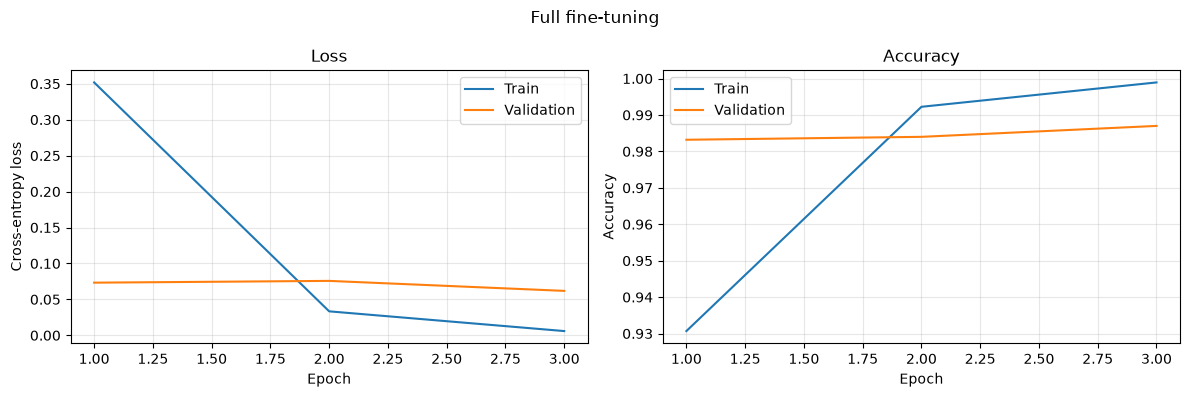

Full fine-tuning: final train acc 0.999 | final val acc 0.987 | gap +0.012 | min val loss 0.062 at epoch 3 | final val loss 0.062


In [43]:
# Full fine-tuning: same epoch budget and data batch as LoRA.
full_hf = load_pretrained_vit()
full_model = HFViT(full_hf).to(DEVICE)
for parameter in full_model.parameters():
    parameter.requires_grad = True

run_experiment(
    "Full fine-tuning",
    full_model,
    pt_loaders,
    EPOCHS_FT,
    LR_FULL,
    weight_decay=0.01,
 )
plot_history(HISTORY["Full fine-tuning"], "Full fine-tuning")
curve_summary("Full fine-tuning")
del full_model, full_hf
cleanup()

## 6. Results comparison  *(Rubric 6)*
Summarize **all** models in a single table: ViT from scratch, CNN, linear probe, LoRA fine-tuning and full fine-tuning. Include at least **test accuracy, trainable parameters (and %), time per epoch and peak GPU memory** for each (all stored in `RESULTS`).

In [44]:
ORDER = ["ViT (scratch)", CNN_NAME, "Linear probe", f"LoRA (r={LORA_R})", "Full fine-tuning"]

def results_table(names):
    '''Return one results row per name that has completed an experiment.'''
    rows = []
    for name in names:
        if name not in RESULTS:
            continue
        result = RESULTS[name]
        rows.append({
            "model": name,
            "val_accuracy_%": result["val_acc"],
            "test_accuracy_%": result["test_acc"],
            "trainable_parameters": result["trainable"],
            "trainable_%": result["pct_trainable"],
            "seconds_per_epoch": result["sec_per_epoch"],
            "peak_gpu_memory_MB": result["peak_mem_mb"],
            "epochs": result["epochs"],
        })
    return pd.DataFrame(rows).set_index("model")

summary = results_table(ORDER)
display(summary)
summary.to_csv("results_summary.csv")

,val_accuracy_%,test_accuracy_%,trainable_parameters,trainable_%,seconds_per_epoch,peak_gpu_memory_MB,epochs
model,,,,,,,
ViT (scratch),78.24,78.43,4249354,100.000000,9.521362,931.034180,30
CNN (Part 1),89.64,89.00,815018,100.000000,5.413280,165.567383,30
Linear probe,96.74,96.46,7690,0.008962,48.678837,492.770996,2
LoRA (r=8),98.78,98.41,302602,0.351418,103.232312,1035.861328,3
Full fine-tuning,98.70,98.62,85806346,100.000000,222.245261,1858.213867,3


### Confusion matrices on the validation set — ViT (scratch) vs. LoRA ViT
Implement `plot_confusions` to plot one confusion matrix per model (side by side), with class names on both axes. Validation predictions and labels are stored in `VAL_PREDS[name]`. `top_confusions` (provided) lists the most frequent (true → predicted) errors.

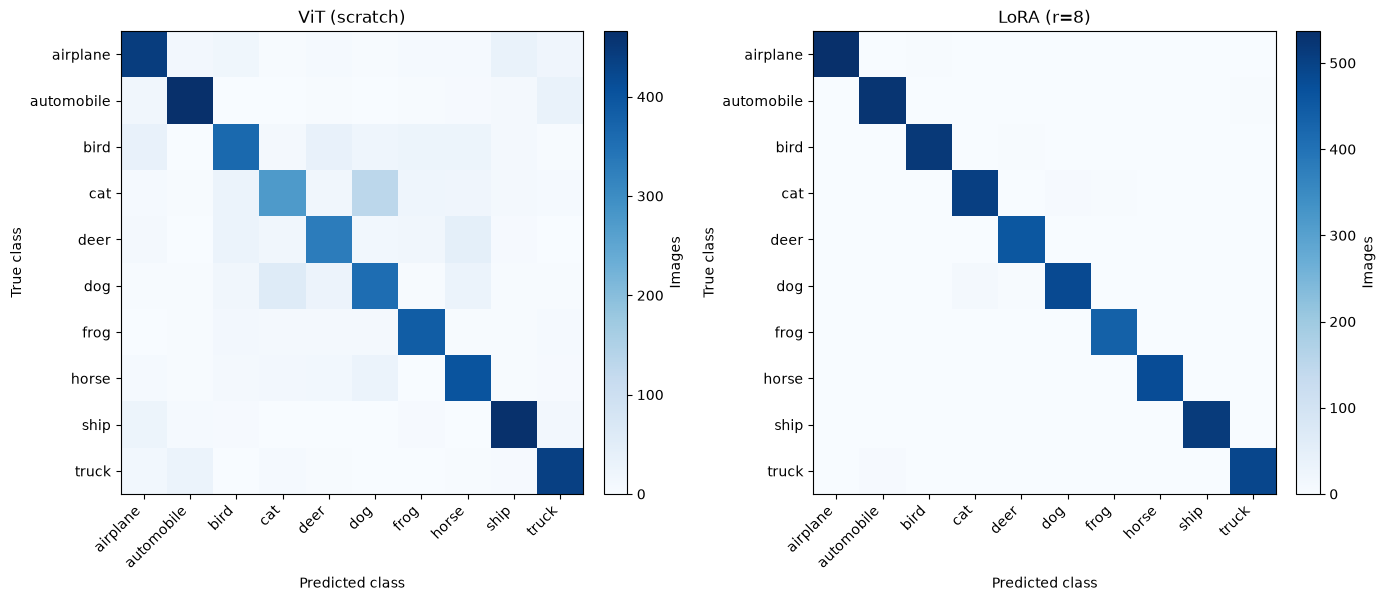

ViT (scratch) - most frequent errors (true -> predicted): cat->dog (130); dog->cat (58); deer->horse (43); bird->airplane (36); bird->deer (34)
LoRA (r=8) - most frequent errors (true -> predicted): dog->cat (9); truck->automobile (6); cat->dog (5); automobile->truck (4); dog->deer (3)


In [45]:
def plot_confusions(names):
    '''Plot the validation confusion matrix of each model in `names` side by side.'''
    fig, axes = plt.subplots(1, len(names), figsize=(7 * len(names), 6), squeeze=False)
    for axis, name in zip(axes.flat, names):
        pred, lab = VAL_PREDS[name]
        matrix = confusion_matrix(lab, pred, labels=range(10))
        image = axis.imshow(matrix, cmap='Blues')
        axis.set_title(name)
        axis.set_xlabel('Predicted class')
        axis.set_ylabel('True class')
        axis.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha='right')
        axis.set_yticks(range(len(CLASSES)), CLASSES)
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label='Images')
    fig.tight_layout()
    plt.show()


def top_confusions(name, k=5):
    pred, lab = VAL_PREDS[name]
    cm = confusion_matrix(lab, pred, labels=range(10)); np.fill_diagonal(cm, 0)
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in range(10) for j in range(10) if cm[i, j]), reverse=True)[:k]
    print(f"{name} - most frequent errors (true -> predicted): " + "; ".join(f"{t}->{p} ({c})" for c, t, p in pairs))

CM_NAMES = ["ViT (scratch)", f"LoRA (r={LORA_R})"]
plot_confusions(CM_NAMES)
for n in CM_NAMES: top_confusions(n)

On the 5,000-image validation set, the scratch ViT made 1,088 errors (78.24% accuracy), while LoRA made 61 (98.78%). The scratch ViT's largest confusions were cat→dog (130), dog→cat (58), and deer→horse (43), with additional bird→airplane and bird→deer errors. LoRA's remaining errors were sparse, led by dog→cat (9) and truck→automobile (6). Both models' errors include visually similar animal and vehicle classes, but the scratch ViT's errors are much more frequent and concentrated in animal pairs.

### Misclassified validation images — LoRA model
Show a grid of **at least 16** misclassified validation images from the LoRA model, with the **predicted and true** label on each.

*Hint:* the validation loader is not shuffled, so position `i` in `VAL_PREDS[name]` corresponds to `VAL_IDX[i]`, and `raw_train.data[VAL_IDX[i]]` gives the un-normalized image.

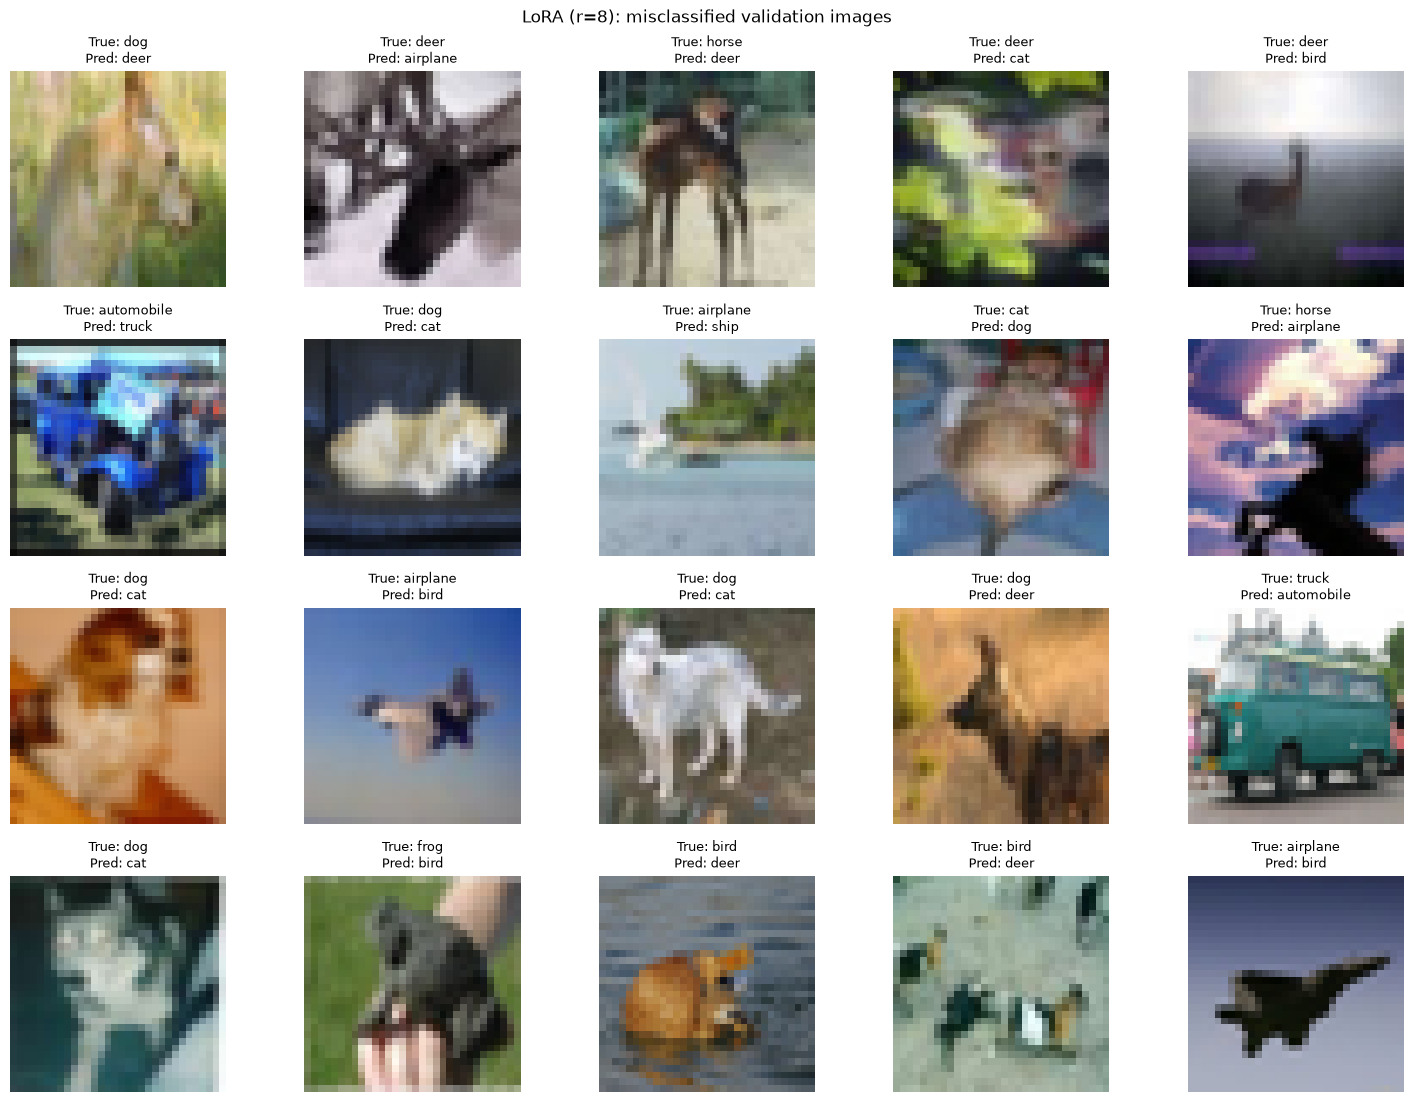

In [46]:
def show_misclassified(name, n=20, cols=5):
    '''Grid of n misclassified validation images from model `name`, titled with predicted and true labels.'''
    pred, labels = VAL_PREDS[name]
    error_indices = np.flatnonzero(pred != labels)[:n]
    if len(error_indices) < n:
        raise ValueError(f"Only {len(error_indices)} misclassified validation examples are available")

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.8 * rows), squeeze=False)
    for axis, val_position in zip(axes.flat, error_indices):
        source_index = VAL_IDX[val_position]
        axis.imshow(raw_train.data[source_index])
        axis.set_title(f'True: {CLASSES[labels[val_position]]}\nPred: {CLASSES[pred[val_position]]}', fontsize=9)
        axis.axis('off')
    for axis in axes.flat[len(error_indices):]:
        axis.axis('off')
    fig.suptitle(f'{name}: misclassified validation images')
    fig.tight_layout()
    plt.show()

show_misclassified(f"LoRA (r={LORA_R})")

The LoRA error grid is dominated by ambiguous 32×32 animal images: dogs are sometimes predicted as cats or deer, deer as birds or cats, and horses as deer. A few small or oddly framed vehicle/aircraft images are also confused. The low resolution leaves little texture or shape detail, while backgrounds and pose can resemble another class.

For the pretrained models, the linear probe is cheapest (7,690 trainable parameters, 48.7 s/epoch, 493 MB peak memory) and reaches 96.46% test accuracy. LoRA trains 302,602 parameters (0.35%), takes 103.2 s/epoch and peaks at 1,036 MB, reaching 98.41%. Full fine-tuning reaches 98.62% with all 85.8M parameters trainable, but costs 222.2 s/epoch and 1,858 MB. Thus LoRA gets close to full fine-tuning accuracy with fewer trainable parameters and lower training cost. The scratch CNN gets 89.00% test accuracy in 5.4 s/epoch; the scratch ViT gets 78.43% in 9.5 s/epoch.

**Change made:** Reduce the LoRA rank from 8 to 4. Keep the same query/value target modules, alpha 16, dropout 0.1, classifier head, learning rate, data split, batch size (`PT_BATCH=8`), and 3-epoch budget.

**Hypothesis (before running):** Rank 4 should use roughly half as many trainable adapter parameters as rank 8. I expect a small accuracy decrease because the adapters have less capacity, with similar epoch time and slightly lower peak memory.

In [47]:
CTRL_R = 4
CTRL_NAME = f"LoRA (r={CTRL_R})"

set_seed()
controlled_lora = make_lora_vit(CTRL_R)
run_experiment(
    CTRL_NAME,
    controlled_lora,
    pt_loaders,
    EPOCHS_FT,
    LR_LORA,
    weight_decay=0.01,
 )
display(results_table([f"LoRA (r={LORA_R})", CTRL_NAME]))
del controlled_lora
cleanup()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 22520.67it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA config: rank=4, alpha=16, dropout=0.1, targets=['q_proj', 'v_proj']
trainable params: 155,146 || all params: 85,961,492 || trainable%: 0.1805

=== LoRA (r=4) | trainable 155,146 / 85,961,492 (0.18%) ===
LoRA (r=4) | epoch 01/3 | train loss 0.1915, acc 95.56% | val loss 0.0861, acc 97.78% | train time 104.1s
LoRA (r=4) | epoch 02/3 | train loss 0.0561, acc 98.56% | val loss 0.0700, acc 98.32% | train time 104.3s
LoRA (r=4) | epoch 03/3 | train loss 0.0135, acc 99.62% | val loss 0.0595, acc 98.70% | train time 104.6s
--> LoRA (r=4): val acc 98.70% | test acc 98.53% | 104.3 s/epoch | peak mem 1034 MB


,val_accuracy_%,test_accuracy_%,trainable_parameters,trainable_%,seconds_per_epoch,peak_gpu_memory_MB,epochs
model,,,,,,,
LoRA (r=8),98.78,98.41,302602,0.351418,103.232312,1035.861328,3
LoRA (r=4),98.70,98.53,155146,0.180483,104.301393,1033.599609,3


**Result:** Rank 4 reduced trainable parameters from 302,602 (0.35%) to 155,146 (0.18%), close to half as hypothesized. Test accuracy did not drop: it was 98.53% for rank 4 versus 98.41% for rank 8. Runtime per epoch was nearly unchanged (104.3 vs. 103.2 seconds), and peak memory was also similar (1,034 vs. 1,036 MB). In this run, halving rank preserved accuracy, but did not noticeably reduce epoch time or peak memory because the frozen ViT backbone dominates computation and activation storage.

## Final summary table (all models + controlled experiment)

In [48]:
final = results_table(ORDER + [CTRL_NAME])
display(final)
final.to_csv("results_summary_all.csv")

,val_accuracy_%,test_accuracy_%,trainable_parameters,trainable_%,seconds_per_epoch,peak_gpu_memory_MB,epochs
model,,,,,,,
ViT (scratch),78.24,78.43,4249354,100.000000,9.521362,931.034180,30
CNN (Part 1),89.64,89.00,815018,100.000000,5.413280,165.567383,30
Linear probe,96.74,96.46,7690,0.008962,48.678837,492.770996,2
LoRA (r=8),98.78,98.41,302602,0.351418,103.232312,1035.861328,3
Full fine-tuning,98.70,98.62,85806346,100.000000,222.245261,1858.213867,3
LoRA (r=4),98.70,98.53,155146,0.180483,104.301393,1033.599609,3


## ✏️ Conclusions

On the identical CIFAR-10 split, the pretrained models substantially outperformed the scratch models. Test accuracies were 78.43% for the scratch ViT, 89.00% for the CNN, 96.46% for the linear probe, 98.41% for LoRA rank 8, and 98.62% for full fine-tuning. LoRA approached full fine-tuning while training only 0.35% of parameters and using about 1.04 GB peak GPU memory instead of 1.86 GB. Reducing LoRA rank to 4 nearly halved trainable parameters while retaining 98.53% test accuracy, with similar time and memory. The scratch CNN outperformed the scratch ViT, consistent with convolutional locality being useful on small images. The pretrained features provided the largest accuracy gain.

For the report, state that pretrained experiments used all 45,000 training examples, `PT_BATCH=8`, two linear-probe epochs, three LoRA/full-fine-tuning epochs, rank 8 (controlled run rank 4), alpha 16, dropout 0.1, and query/value targets. The local Colab Drive and package-install workarounds were skipped; dependencies were installed in the project environment.

### Notes on Part 2 - Check that:
- [x] The same 45k / 5k / 10k split is used for every model, and it is documented in section 1
- [x] Both ViT sanity checks (tiny-batch overfit and tensor shapes) are shown
- [x] `PT_BATCH=8` is reported as the change from the default
- [x] Required local cells ran with outputs and plots visible; Colab-only setup cells were skipped
- [ ] AI assistance is documented in the PDF report